In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as web

/Users/kostaskar/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
start = "1990-01-01"
end = "2024-12-31"

series = {
    "y": "GDPC1",
    "i": "FEDFUNDS",
    "g": "GCEC1",
    "m": "M2SL",
    "p": "CPIAUCSL",
    "e": "RBUSBIS"
}

In [3]:
data = pd.DataFrame()

for name, code in series.items():
    data[name] = web.DataReader(code, "fred", start, end)

data.head()

,y,i,g,m,p,e
DATE,,,,,,
1990-01-01,10047.386,8.23,2534.913,3166.8,127.5,NaN
1990-04-01,10083.855,8.26,2538.916,3201.6,128.9,NaN
1990-07-01,10090.569,8.15,2542.963,3224.5,130.5,NaN
1990-10-01,9998.704,8.11,2559.964,3259.3,133.4,NaN
1991-01-01,9951.916,6.91,2575.220,3287.7,134.7,NaN


In [4]:
data_q = data.resample("Q").mean()

data_q = data_q.dropna()

data_q.head()

/var/folders/tt/kh_xz3rx6wj9dm9y4yvs49x80000gn/T/ipykernel_3000/3175153043.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  data_q = data.resample("Q").mean()


,y,i,g,m,p,e
DATE,,,,,,
1994-03-31,10939.116,3.05,2542.324,3474.9,146.3,88.66
1994-06-30,11087.361,3.56,2554.916,3481.3,147.2,88.18
1994-09-30,11152.176,4.26,2597.991,3488.2,148.4,85.93
1994-12-31,11279.932,4.76,2575.394,3484.3,149.4,84.05
1995-03-31,11319.951,5.53,2584.415,3492.4,150.5,88.00


In [5]:
df = pd.DataFrame()

df["log_y"] = np.log(data_q["y"])

df["interest"] = data_q["i"]

df["log_g"] = np.log(data_q["g"])

df["log_m_real"] = np.log(data_q["m"] / data_q["p"])

df["log_e"] = np.log(data_q["e"])

df = df.dropna()

df.head()

,log_y,interest,log_g,log_m_real,log_e
DATE,,,,,
1994-03-31,9.300100,3.05,7.840834,3.167662,4.484809
1994-06-30,9.313561,3.56,7.845775,3.163369,4.479380
1994-09-30,9.319390,4.26,7.862494,3.157230,4.453533
1994-12-31,9.330780,4.76,7.853758,3.149395,4.431412
1995-03-31,9.334322,5.53,7.857254,3.144381,4.477337


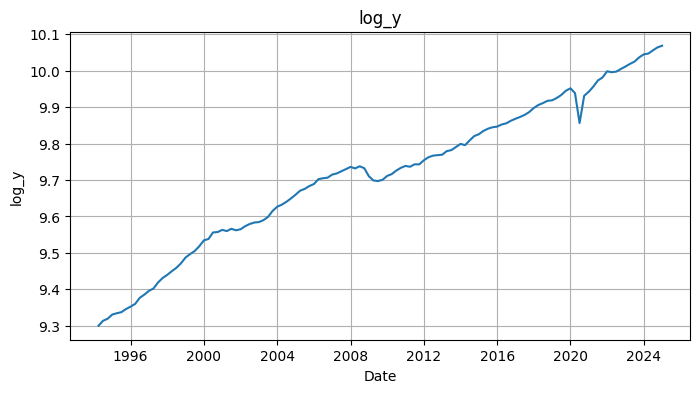

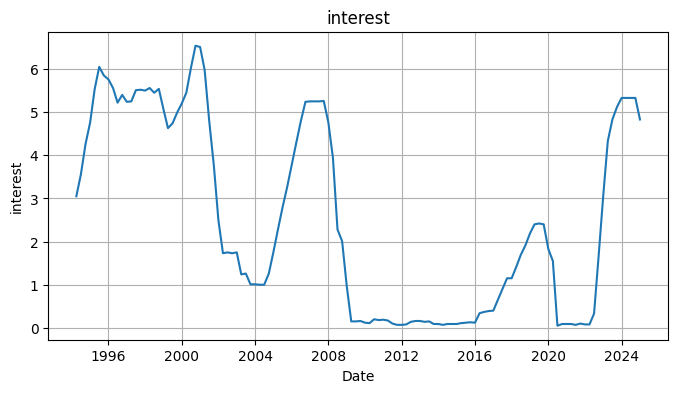

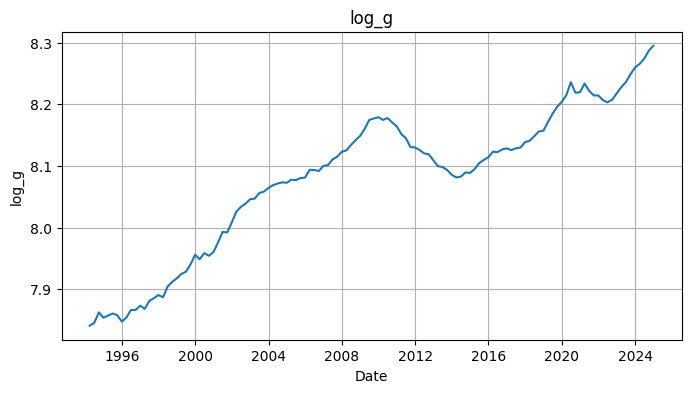

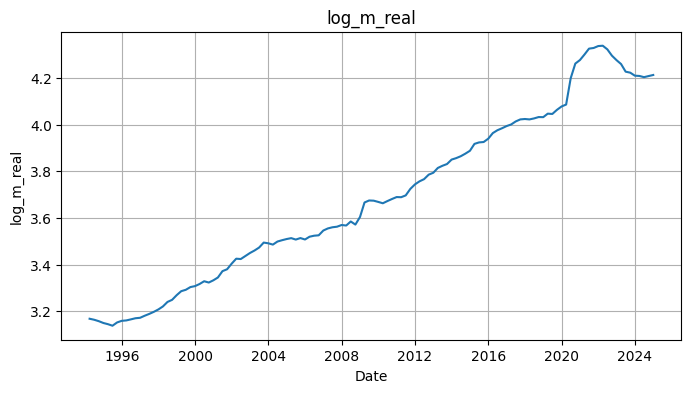

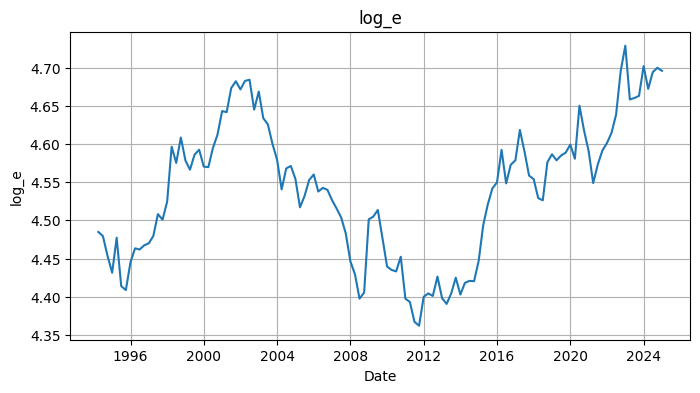

In [6]:
for col in df.columns:
    plt.figure(figsize=(8,4))
    plt.plot(df.index, df[col])
    plt.title(col)
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

In [7]:
import statsmodels.api as sm

Y = df["log_y"]

X_is = df[["interest", "log_g", "log_e"]]

X_is = sm.add_constant(X_is)

is_model = sm.OLS(Y, X_is).fit()

print(is_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  log_y   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     367.3
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           2.84e-60
Time:                        14:33:41   Log-Likelihood:                 165.98
No. Observations:                 124   AIC:                            -324.0
Df Residuals:                     120   BIC:                            -312.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.9013      0.481     -8.109      0.0

In [8]:
Y_lm = df["interest"]

X_lm = df[["log_y", "log_m_real"]]

X_lm = sm.add_constant(X_lm)

lm_model = sm.OLS(Y_lm, X_lm).fit()

print(lm_model.summary())

                            OLS Regression Results                            
Dep. Variable:               interest   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     27.57
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.36e-10
Time:                        14:33:41   Log-Likelihood:                -252.43
No. Observations:                 124   AIC:                             510.9
Df Residuals:                     121   BIC:                             519.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -47.3033     26.891     -1.759      0.0

In [9]:
from statsmodels.tsa.api import VAR

var_data = df[["log_y", "interest", "log_g", "log_e"]]

model = VAR(var_data)

lag_selection = model.select_order(maxlags=8)

print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -13.61      -13.52   1.225e-06      -13.57
1      -28.08      -27.61   6.353e-13      -27.89
2      -28.65     -27.79*  3.629e-13*     -28.30*
3      -28.63      -27.39   3.710e-13      -28.13
4     -28.65*      -27.03   3.651e-13      -27.99
5      -28.49      -26.49   4.320e-13      -27.68
6      -28.26      -25.89   5.486e-13      -27.30
7      -28.13      -25.38   6.335e-13      -27.01
8      -28.07      -24.93   6.902e-13      -26.79
-------------------------------------------------


In [10]:
var_results = model.fit(lag_selection.aic)

print(var_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 08, Jun, 2026
Time:                     14:33:41
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -26.9725
Nobs:                     120.000    HQIC:                  -27.9106
Log likelihood:           1100.03    FPE:                4.01169e-13
AIC:                     -28.5521    Det(Omega_mle):     2.36140e-13
--------------------------------------------------------------------
Results for equation log_y
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.107251         0.140155            0.765           0.444
L1.log_y            0.820775         0.114172            7.189           0.000
L1.interest        -0.004046         0.003919           -1.032      

/Users/kostaskar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1501: RuntimeWarning: divide by zero encountered in matmul
  return np.kron(np.linalg.inv(z.T @ z), self.sigma_u)
/Users/kostaskar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1501: RuntimeWarning: overflow encountered in matmul
  return np.kron(np.linalg.inv(z.T @ z), self.sigma_u)
/Users/kostaskar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1501: RuntimeWarning: invalid value encountered in matmul
  return np.kron(np.linalg.inv(z.T @ z), self.sigma_u)


/Users/kostaskar/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/kostaskar/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/kostaskar/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Users/kostaskar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1548: RuntimeWarning: divide by zero encountered in matmul
  return 2 * D_Kinv @ sigxsig @ D_Kinv.T
/Users/kostaskar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1548: RuntimeWarning: overflow encountered in matmul
  return 2 * D_Kinv @ sigxsig @ D_Kinv.T
/Users/kostaskar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_

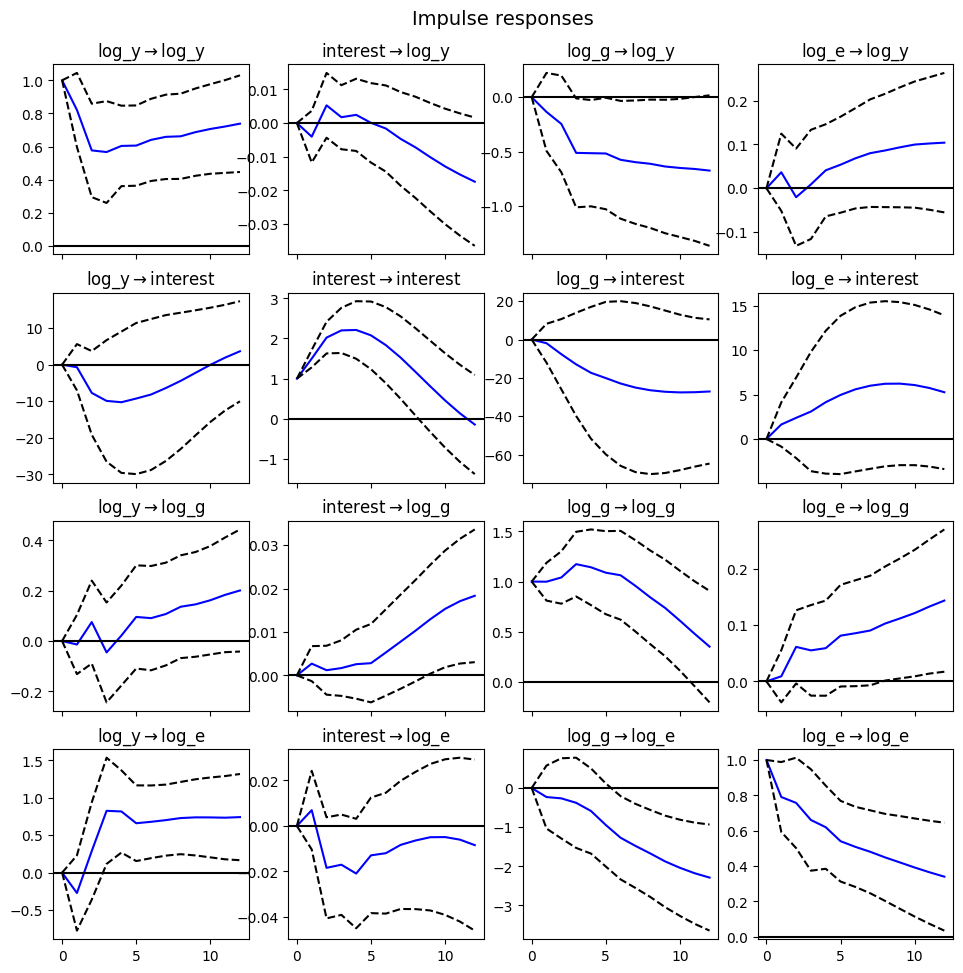

In [11]:
irf = var_results.irf(12)

irf.plot()

plt.show()

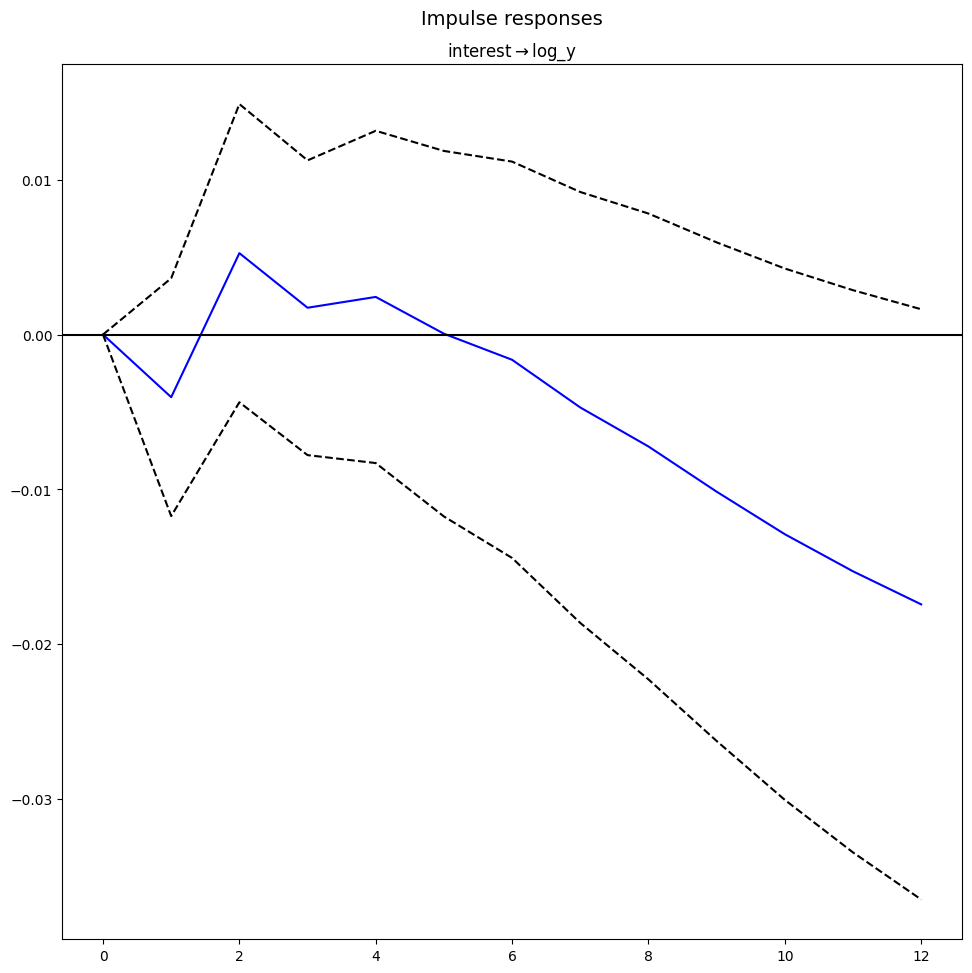

In [12]:
irf.plot(
    impulse="interest",
    response="log_y"
)

plt.show()

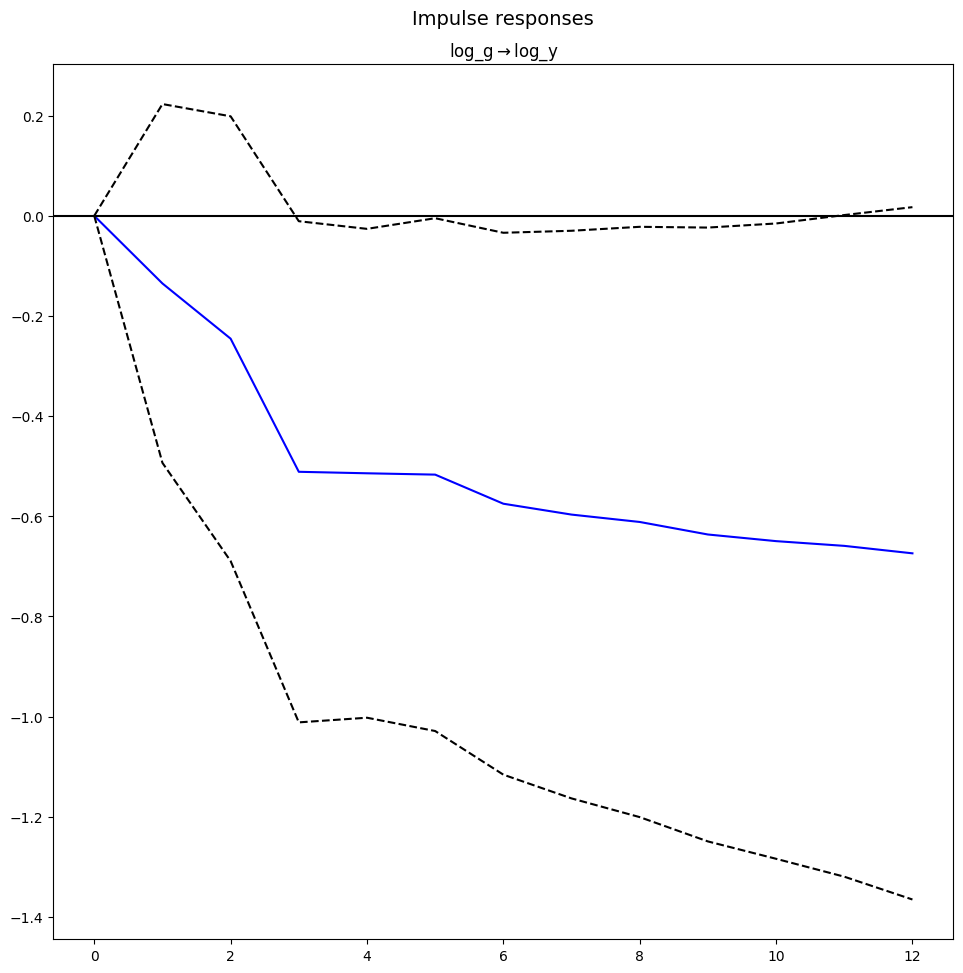

In [13]:
irf.plot(
    impulse="log_g",
    response="log_y"
)

plt.show()

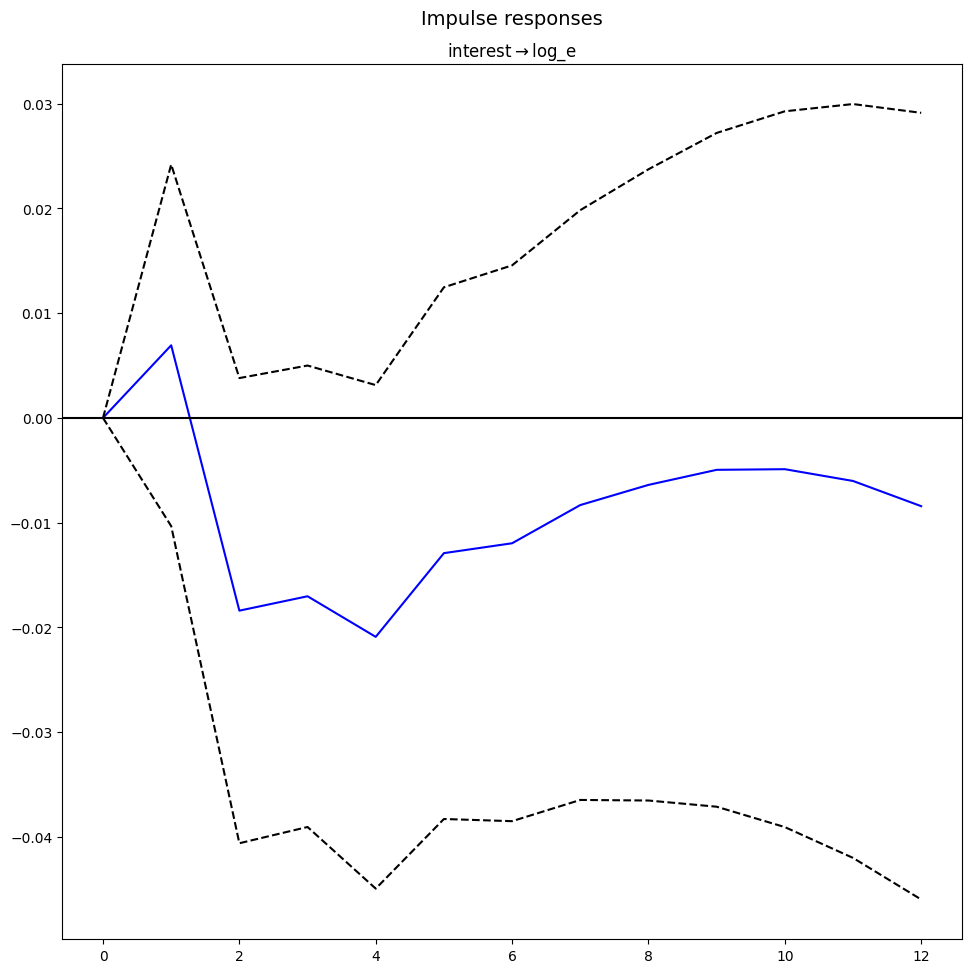

In [14]:
irf.plot(
    impulse="interest",
    response="log_e"
)

plt.show()

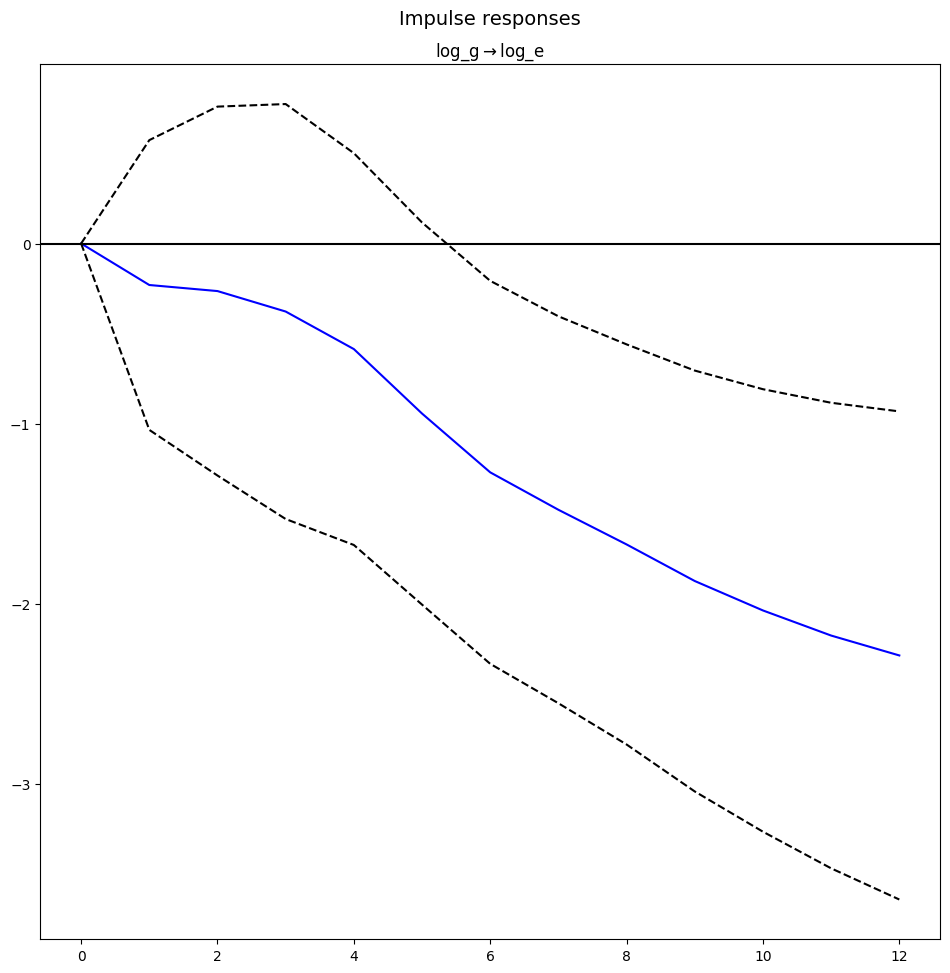

In [15]:
irf.plot(
    impulse="log_g",
    response="log_e"
)

plt.show()

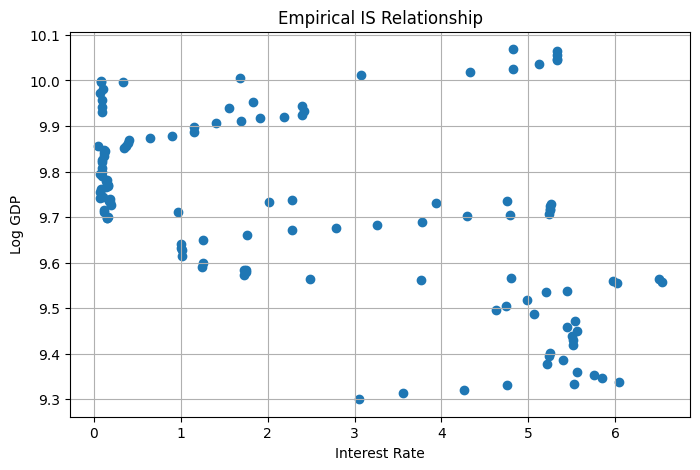

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["interest"],
    df["log_y"]
)

plt.xlabel("Interest Rate")
plt.ylabel("Log GDP")
plt.title("Empirical IS Relationship")

plt.grid(True)

plt.show()

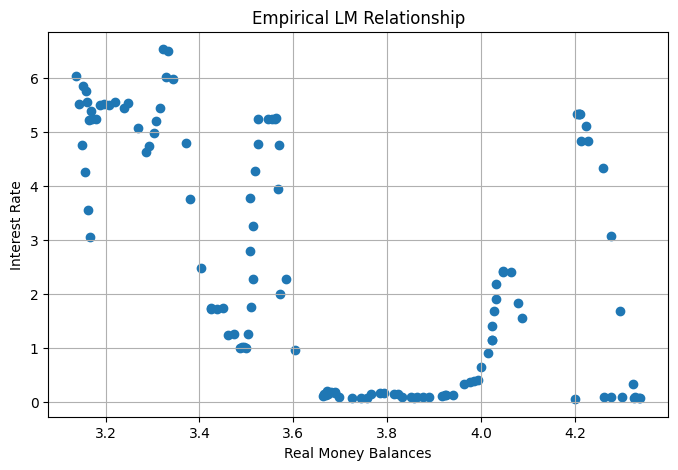

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["log_m_real"],
    df["interest"]
)

plt.xlabel("Real Money Balances")
plt.ylabel("Interest Rate")
plt.title("Empirical LM Relationship")

plt.grid(True)

plt.show()